In [1]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
from pygam import LinearGAM, s, f, te
import matplotlib.pyplot as plt
import data_processing_functions as helpy
import manual_ml_stuff as ml
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
receiving = helpy.get_dataset()

In [3]:
print(receiving)

             player  player_id position   team_name  player_game_count  \
0      Amari Cooper       9437       WR     ALABAMA                 14   
1      Justin Hardy       9540       WR  E CAROLINA                 13   
2       Vince Mayle       9556       WR  WASH STATE                 12   
3       Kevin White       9440       WR  W VIRGINIA                 13   
4     Jaelen Strong       9503       WR  ARIZONA ST                 12   
..              ...        ...      ...         ...                ...   
988  Jayden Higgins     150240       WR  IOWA STATE                 13   
989   Travis Hunter     160766       CB    COLORADO                  9   
990   Travis Hunter     160766       CB    COLORADO                 13   
991    Isaac TeSlaa     172430       WR    ARKANSAS                 12   
992    Isaac TeSlaa     172430       WR    ARKANSAS                 13   

     drop_rate  wide_rate  yprr  targets  behind_los_yards  ...  deep_yards  \
0          6.1       79.6  3.99 

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

skills in order: efficency vs man and zone seperately, threat to all parts of the field, drops, positional value, translatability 

In [5]:
X = receiving[['behind_los_ypg', 'short_ypg', 'medium_ypg', 'deep_ypg', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate']]
    
y = receiving['pick']

In [6]:
X = X.fillna(0)

In [7]:
X['is_power_four'] = X['is_power_four'].astype(np.float32)

In [8]:
X_norm = (X - X.min()) / (X.max() - X.min())

In [9]:
# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

In [10]:
# Dataset & DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [11]:
model = ml.NonMonotoneMultiplicativeModel()
loss_fn = nn.MSELoss()  # regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    epoch_loss = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()              # Step 1: reset gradients
        y_pred = model(x_batch)            # Step 2: forward pass
        loss = loss_fn(y_pred, y_batch)   # Step 3: compute loss
        loss.backward()                    # Step 4: backward pass (compute gradients)
        optimizer.step()                   # Step 5: update weights
        epoch_loss += loss.item() * x_batch.size(0)
    
    epoch_loss /= len(dataloader.dataset)
    return epoch_loss

In [13]:
n_epochs = 500
epoch_losses = []

for epoch in range(n_epochs):
    
    epoch_loss = train_one_epoch(dataloader, model, loss_fn, optimizer)
    
    num_worse_than = 0
    
    if epoch > 30:
        for loss in epoch_losses[-20:]:
            if loss < epoch_loss:
                num_worse_than = num_worse_than + 1
                
        if num_worse_than > 15:
            n_epochs = epoch
            break
        
    epoch_losses.append(epoch_loss)
    

In [14]:
model.eval()
with torch.no_grad():  # no gradients needed for prediction
    y_pred = model(X_tensor)  # X: tensor of shape (num_samples, 11)
receiving['predicted_slot'] = y_pred

idx = receiving.groupby("player")["predicted_slot"].idxmin()
receiving_best = receiving.loc[idx]

In [15]:
X = receiving_best[['behind_los_ypg', 'short_ypg', 'medium_ypg', 'deep_ypg', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate']]
    
y = receiving_best['pick']

X = X.fillna(0)
X['is_power_four'] = X['is_power_four'].astype(np.float32)
X_norm = (X - X.min()) / (X.max() - X.min())

X_tensor = torch.tensor(X_norm.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = ml.NonMonotoneMultiplicativeModel()
loss_fn = nn.MSELoss()  # regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
n_epochs = 500
epoch_losses = []

for epoch in range(n_epochs):
    
    epoch_loss = train_one_epoch(dataloader, model, loss_fn, optimizer)
    
    num_worse_than = 0
    
    if epoch > 30:
        for loss in epoch_losses[-20:]:
            if loss < epoch_loss:
                num_worse_than = num_worse_than + 1
                
        if num_worse_than > 15:
            n_epochs = epoch
            break
        
    epoch_losses.append(epoch_loss)
    

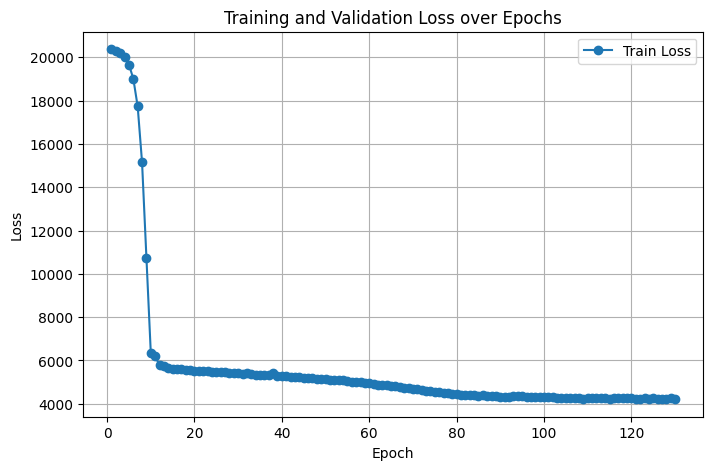

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), epoch_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
model.eval()
with torch.no_grad():  # no gradients needed for prediction
    y_pred = model(X_tensor)  # X: tensor of shape (num_samples, 11)

In [19]:
receiving_best['predicted_slot'] = y_pred

reference_values = np.sort(receiving_best["predicted_slot"].values)
n = len(reference_values)

def percentile_from_reference(values, reference):
    return np.searchsorted(reference, values, side="right") / len(reference) * 100

receiving_best["percentile"] = percentile_from_reference(
    receiving_best["predicted_slot"].values,
    reference_values
)

In [20]:
receiving_best[['behind_los_ypg', 'short_ypg', 'medium_ypg', 'deep_ypg', 'yprr',
                'is_power_four', 'drop_rate', 'wide_rate', 'player', 'team_name', 'is_power_four', 'predicted_slot', 'percentile']]

,behind_los_ypg,short_ypg,medium_ypg,deep_ypg,yprr,is_power_four,drop_rate,wide_rate,player,team_name,is_power_four,predicted_slot,percentile
329,8.666667,38.083333,29.916667,32.250000,3.01,True,5.6,40.4,A.J. Brown,OLE MISS,True,85.234886,16.504854
743,0.000000,26.642857,21.785714,44.142857,2.66,True,11.3,90.3,A.T. Perry,WAKE,True,110.909149,39.482201
112,2.500000,18.642857,34.785714,33.928571,2.85,True,10.5,81.1,Aaron Burbridge,MICH STATE,True,104.393234,33.009709
927,1.500000,12.142857,25.142857,21.571429,1.72,True,1.8,81.6,Adonai Mitchell,TEXAS,True,144.995529,77.022654
704,3.750000,27.333333,15.166667,20.000000,2.27,True,1.9,23.8,Ainias Smith,TEXAS A&M,True,140.785172,74.433657
665,0.571429,14.071429,16.857143,30.857143,2.38,True,7.1,84.7,Alec Pierce,CINCINNATI,True,132.848846,65.695793
91,7.307692,20.384615,17.153846,21.461538,2.45,True,9.5,90.9,Amara Darboh,MICHIGAN,True,126.709717,58.252427
0,24.642857,38.857143,21.928571,37.928571,3.99,True,6.1,79.6,Amari Cooper,ALABAMA,True,51.765240,2.588997
481,20.750000,22.166667,19.333333,22.750000,2.61,True,7.2,13.2,Amari Rodgers,CLEMSON,True,96.504013,25.889968
546,9.076923,23.307692,18.846154,28.923077,1.94,True,6.1,10.1,Amon-Ra St. Brown,USC,True,121.611305,53.398058


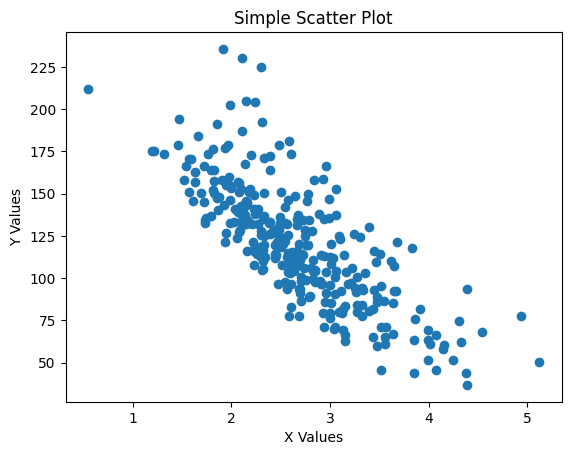

In [21]:
plt.scatter(receiving_best['yprr'], receiving_best['predicted_slot'])

plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.title("Simple Scatter Plot")

plt.show()

In [22]:
prospect_list = helpy.get_2026_prospects()

X = prospect_list[['behind_los_ypg', 'short_ypg', 'medium_ypg', 'deep_ypg', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate']]

X = X.fillna(0)
X['is_power_four'] = X['is_power_four'].astype(np.float32)
X_norm = (X - X.min()) / (X.max() - X.min())
X_norm = X_norm.fillna(1)

X_tensor = torch.tensor(X_norm.values, dtype=torch.float32)

In [23]:
X_tensor

tensor([[0.8079, 0.5735, 0.3553,  ..., 1.0000, 0.1329, 0.0512],
        [0.2841, 0.4278, 0.6335,  ..., 1.0000, 0.1119, 0.8205],
        [0.6794, 0.7282, 0.5985,  ..., 1.0000, 0.0909, 0.0672],
        ...,
        [0.0849, 0.1613, 0.0566,  ..., 1.0000, 0.1573, 0.0160],
        [0.0444, 0.0926, 0.1301,  ..., 1.0000, 0.3671, 0.8506],
        [0.0504, 0.2113, 0.0240,  ..., 1.0000, 0.4196, 0.0281]])

In [24]:
model.eval()
with torch.no_grad():  # no gradients needed for prediction
    y_pred = model(X_tensor)  # X: tensor of shape (num_samples, 11)

In [25]:
prospect_list['predicted_slot'] = y_pred

prospect_list["percentile"] = percentile_from_reference(
    prospect_list["predicted_slot"].values,
    reference_values
)

In [26]:
prospect_list[['team_name', 'is_power_four', 'percentile']]

,team_name,is_power_four,percentile
1,OKLA STATE,True,53.721683
2,WASHINGTON,True,3.559871
3,VIRGINIA,True,1.618123
7,ARIZONA,True,6.148867
8,LSU,True,1.618123
9,ILLINOIS,True,14.886731
12,ARIZONA,True,48.543689
16,MISSOURI,True,2.912621
17,TEXAS,True,21.359223
18,MIAMI FL,True,20.064725


In [27]:
prospect_list['player']

1               Brennan Presley
2                   Rome Odunze
3              Malik Washington
7             Tetairoa McMillan
8                  Malik Nabers
9               Isaiah Williams
12                 Jacob Cowing
16            Luther Burden III
17                Xavier Worthy
18              Xavier Restrepo
20               Lincoln Victor
23          Marvin Harrison Jr.
24                Troy Franklin
26                 Will Pauling
28                 Ja'Lynn Polk
29                 Drake Stoops
30               Daniel Jackson
31                Elic Ayomanor
32                  Tez Johnson
34                 Jordan Moore
35                KC Concepcion
41               Malachi Fields
44                Xavier Weaver
45               Elijhah Badger
46                 Rashod Owens
51            Xzavier Henderson
52              Jeremiah Hunter
53               Xavier Legette
56                Jamari Thrash
57               Squirrel White
59                  Deion Burks
63      